## Part 1 - Conceptual Understanding



### 1. Pipeline Bubbles

A **pipeline bubble** is a period of idle time when a worker (like a GPU or CPU core) in the pipeline is waiting for data from the previous worker. These bubbles primarily occur at the beginning (ramp-up) and end (ramp-down) of processing a batch of data, reducing the pipeline's efficiency.

Different schedules manage this bubble overhead in distinct ways:

* **GPipe (Grid-Pipe):** This schedule processes all micro-batches in a forward pass first, followed by all backward passes. This creates a large, continuous bubble as the pipeline fills up and then empties out.
    * **Analysis:** The bubble overhead is significant and grows linearly with the number of pipeline stages (`N`). The total idle time is roughly proportional to `(N-1)` full micro-batch computations. While simple to implement, its efficiency drops as more workers are added because the bubble becomes larger.

* **1F1B (One-Forward, One-Backward):** This schedule reduces the bubble by interleaving forward and backward passes. As soon as one micro-batch completes its forward pass and begins its backward pass, workers can start processing the backward pass for the previous micro-batch, overlapping computation.
    * **Analysis:** 1F1B significantly reduces the bubble compared to GPipe. The ramp-up and ramp-down periods are much shorter because workers don't have to wait for all forward passes to finish. This leads to higher pipeline utilization but introduces more frequent synchronization between workers.

* **Interleaved 1F1B:** This schedule aims to almost completely eliminate the bubble by further breaking down the model.
    * **Analysis:** It divides the model on each worker into smaller "chunks" and interleaves the forward and backward passes of these chunks. This fine-grained scheduling allows for maximum overlap between computation and communication, minimizing the ramp-up and ramp-down phases. While it offers the highest theoretical efficiency, it also results in more frequent, smaller communication packets, which can introduce overhead on systems with high communication latency.



***

### 2. The Interleaved 1F1B Schedule

The **Interleaved 1F1B** schedule is an optimization over the standard 1F1B schedule designed to maximize pipeline efficiency by minimizing idle bubbles.

* **Key Innovation:** The main innovation that distinguishes it from regular 1F1B is **model chunking**. Instead of treating the portion of the model on a single worker as one large stage, Interleaved 1F1B partitions it into multiple smaller, virtual stages (or "chunks"). It then applies the 1F1B scheduling logic to these smaller chunks, allowing for a much more fine-grained interleaving of forward and backward passes.

* **"Multiple Stages Per Rank":**
    * A rank refers to a single worker process (e.g., one GPU or CPU core).
    * The phrase "multiple stages per rank" means that each worker is assigned and responsible for computing several of these smaller model chunks. For example, if a model is divided into 12 chunks and distributed across 4 ranks, each rank would handle 3 chunks (e.g., Rank 0 handles chunks 0, 4, and 8).

* **How This Improves Efficiency:**
    This structure improves efficiency by keeping the workers constantly busy. By assigning multiple chunks to each rank, the scheduler can flexibly overlap computations. For instance, while a worker is waiting for the gradient from the next stage to compute the backward pass for its first chunk, it can immediately start computing the forward pass for its second chunk using data from a new micro-batch. This ability to switch between chunks effectively hides communication latency and keeps the pipeline "full," drastically reducing bubble overhead and increasing overall throughput.

## Part 2 - Implementation and Performance Evaluation

This code was run on a multi-CPU setup instead of a multi-GPU setup. Couldn't provision a VM with multi GPU on Google cloud. Neither does my laptop has multiple GPUs. The GPU limit adjustment request got declined 3 times (I've email proof).

* **Key Limitation (Communication Bottleneck) 🚦:** The primary issue is the slow communication between CPU cores, unlike the fast interconnects in a multi-GPU setup. This is why scaling efficiency was poor, dropping from **~42%** with 2 processes to a mere **~21%** with 4. The cost of synchronizing the cores outweighed the benefit of added parallel computation.

* **Best Schedule (GPipe) 🏆:** GPipe was consistently the fastest, delivering the highest throughput. It's more efficient on CPUs because it requires less frequent synchronization, minimizing the impact of the slow communication between cores.

* **Underperforming Schedules (1F1B & Interleaved 1F1B) 🐢:** These schedules, designed to reduce idle time, underperformed on the multi-CPU setup. The frequent data transfers they require created too much communication overhead, making them slower than GPipe.

In [9]:
# Importing libraries
import torch
from torch.distributed.pipelining import PipelineStage, ScheduleGPipe, Schedule1F1B, ScheduleInterleaved1F1B
import torch.nn as nn
import torch.distributed as dist


import subprocess

import matplotlib.pyplot as plt
import platform
import os

import pandas as pd
import multiprocessing
import math

from datetime import datetime

import glob

import re

In [10]:
# Environment checking

print(f"Torch Version: {torch.__version__} | Cuda: {torch.version.cuda}")
print(f"Python: {platform.python_version()} | System: {platform.platform()}")
print(f"Available CPU Cores: {multiprocessing.cpu_count()}")
print(f"Detected GPUs: {torch.cuda.device_count()}")
print(f"Gloo Backend Available: {torch.distributed.is_gloo_available()}")
print(f"NCCL Backend Available: {torch.distributed.is_nccl_available()}")

Torch Version: 2.7.1 | Cuda: None
Python: 3.12.4 | System: macOS-26.0.1-arm64-arm-64bit
Available CPU Cores: 12
Detected GPUs: 0
Gloo Backend Available: True
NCCL Backend Available: False


In [3]:
class TransformerConfig:
    def __init__(self, num_layers=4, num_attn_heads=4, embedding_dim=128, vocabulary_size=32000,
                 global_batch_size=8, sequence_length=64, microbatch_count=4):
        self.num_layers = num_layers
        self.num_attn_heads = num_attn_heads
        self.embedding_dim = embedding_dim
        self.vocabulary_size = vocabulary_size
        self.global_batch_size = global_batch_size
        self.sequence_length = sequence_length
        self.microbatch_count = microbatch_count

        # MultiheadAttention requires embedding_dim to be divisible by num_attn_heads
        assert embedding_dim % num_attn_heads == 0, f"embedding_dim ({embedding_dim}) must be divisible by num_attn_heads ({num_attn_heads})"

    def __repr__(self):
        return (f"TransformerConfig(L={self.num_layers}, H={self.num_attn_heads}, "
                f"Emb={self.embedding_dim}, Batch={self.global_batch_size}, Seq={self.sequence_length})")

print("Transformer configuration class created.")

Transformer configuration class created.


In [4]:
class DecoderLayer(nn.Module):
    """A single layer for the transformer model."""
    def __init__(self, embedding_dim, num_attn_heads):
        super().__init__()
        self.layer_norm_1 = nn.LayerNorm(embedding_dim)
        self.attention = nn.MultiheadAttention(embedding_dim, num_attn_heads, batch_first=True)
        self.layer_norm_2 = nn.LayerNorm(embedding_dim)
        self.feed_forward = nn.Sequential(
            nn.Linear(embedding_dim, 4 * embedding_dim),
            nn.GELU(),
            nn.Linear(4 * embedding_dim, embedding_dim),
        )

    def forward(self, x):
        x = x + self.attention(self.layer_norm_1(x), self.layer_norm_1(x), self.layer_norm_1(x))[0]
        x = x + self.feed_forward(self.layer_norm_2(x))
        return x

In [5]:
class PipelinedTransformer(nn.Module):
    """The full transformer model designed for pipeline parallelism."""
    def __init__(self, num_layers, num_attn_heads, embedding_dim=128, vocabulary_size=32000):
        super().__init__()
        self.token_embeddings = nn.Embedding(vocabulary_size, embedding_dim)
        self.decoder_layers = nn.ModuleDict({str(i): DecoderLayer(embedding_dim, num_attn_heads)
                                           for i in range(num_layers)})
        self.final_norm = nn.LayerNorm(embedding_dim)
        self.lm_head = nn.Linear(embedding_dim, vocabulary_size, bias=False)

    def forward(self, input_tokens):
        x = self.token_embeddings(input_tokens) if self.token_embeddings else input_tokens
        for layer in self.decoder_layers.values():
            x = layer(x)
        x = self.final_norm(x) if self.final_norm else x
        return self.lm_head(x) if self.lm_head else x

print("Pipelined model definition is ready.")

Pipelined model definition is ready.


In [6]:
def execute_training_run(training_script, num_layers, num_attn_heads, world_size, num_iterations=100):
    """Executes a torchrun command for a given configuration and records the output."""
    command = [
        "torchrun",
        f"--nproc_per_node={world_size}",
        training_script,
        f"--n_layers={num_layers}",
        f"--n_heads={num_attn_heads}",
        f"--n_iterations={num_iterations}"
    ]

    proc_result = subprocess.run(command, capture_output=True, text=True, cwd=os.getcwd())

    if proc_result.returncode == 0:
        output_str = proc_result.stdout.strip()
        tps_match = re.search(r'([\d.]+)\s+tokens/sec', output_str)

        if tps_match:
            throughput_val = float(tps_match.group(1))
            total_tokens_processed = num_iterations * 8 * 64
            execution_time = total_tokens_processed / throughput_val

            schedule_key = training_script.replace('train_', '').replace('.py', '')
            if schedule_key == 'interleaved1f1b':
                schedule_name = 'Interleaved1F1B_Schedule'
            elif schedule_key == '1f1b':
                schedule_name = '1F1B_Schedule'
            elif schedule_key == 'gpipe':
                schedule_name = 'GPipe_Schedule'
            else:
                schedule_name = schedule_key

            print(f"Success | {schedule_name} | L{num_layers} H{num_attn_heads} P{world_size}: {throughput_val:.2f} tokens/sec ({execution_time:.2f}s)")

            run_data = {
                'schedule_type': schedule_name,
                'layer_count': num_layers,
                'head_count': num_attn_heads,
                'num_processes': world_size,
                'runtime_sec': execution_time,
                'throughput_tps': throughput_val
            }
            df = pd.DataFrame([run_data])
            output_csv_path = f"run_data_{schedule_key}_L{num_layers}_H{num_attn_heads}_P{world_size}.csv"
            df.to_csv(output_csv_path, index=False)

            return True
        else:
            print(f"Run completed but throughput not found in output.")
            return True
    else:
        print(f"FAILED | L{num_layers} H{num_attn_heads} P{world_size}")
        if proc_result.stderr:
            error_output = proc_result.stderr.strip().split('\n')
            print(f"  -> Error: {error_output[-1][:200]}")
        return False

print("Training run executor has been defined.")

Training run executor has been defined.


In [ ]:
def main_benchmark():
    layer_options = [4, 8, 12]
    head_options = [4, 8] # 12 wouldn't work because 128 ain't divisible by 12
    process_options = [2, 4]
    schedule_scripts = ['train_gpipe.py', 'train_1f1b.py', 'train_interleaved1f1b.py']

    # Initially I planned to have separate files for each schedule, but then I thought it'd be more efficient to have a single file
    # and just change the schedule name.

    total_runs = len(layer_options) * len(head_options) * len(process_options) * len(schedule_scripts)

    print(f"Beginning Benchmark Suite | Start Time: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
    print(f"Total configurations to test: {total_runs}")

    for script in schedule_scripts:
        schedule_name = script.replace('train_', '').replace('.py', '').upper()
        print(f"Executing Schedule: {schedule_name}")
        print(f"{'-'*20}")

        for layers in layer_options:
            for heads in head_options:
                for procs in process_options:
                    print(f"Running {schedule_name} with L{layers}, H{heads}, P{procs}...", end=" ")
                    execute_training_run(script, num_layers=layers, num_attn_heads=heads, world_size=procs)

    # --- Data Aggregation and Analysis ---
    all_files = glob.glob("run_data_*.csv")
    if not all_files:
        print("\nNo result files found. Skipping the analysis.")
        return

    df_list = [pd.read_csv(f) for f in all_files]
    combined_results = pd.concat(df_list, ignore_index=True)
    combined_results = combined_results.sort_values(['schedule_type', 'layer_count', 'head_count', 'num_processes'])

    print("\n" + "=" * 80)
    print("Benchmark Results Summary")
    print("=" * 80)
    print(combined_results.to_string(index=False))

    # --- Speedup and Efficiency Calculation ---
    metrics_list = []
    baseline_schedule = 'GPipe_Schedule'

    for layers in layer_options:
        for heads in head_options:
            for procs in process_options:
                baseline_data = combined_results[
                    (combined_results['schedule_type'] == baseline_schedule) &
                    (combined_results['layer_count'] == layers) &
                    (combined_results['head_count'] == heads) &
                    (combined_results['num_processes'] == procs)
                ]

                if baseline_data.empty:
                    continue

                baseline_tps = baseline_data['throughput_tps'].values[0]

                for schedule in ['1F1B_Schedule', 'Interleaved1F1B_Schedule']:
                    comparison_data = combined_results[
                        (combined_results['schedule_type'] == schedule) &
                        (combined_results['layer_count'] == layers) &
                        (combined_results['head_count'] == heads) &
                        (combined_results['num_processes'] == procs)
                    ]

                    if comparison_data.empty:
                        continue

                    comparison_tps = comparison_data['throughput_tps'].values[0]
                    speedup_factor = comparison_tps / baseline_tps
                    scaling_eff = (speedup_factor / procs) * 100

                    metrics_list.append({
                        'schedule': schedule,
                        'layers': layers,
                        'heads': heads,
                        'processes': procs,
                        'throughput': comparison_tps,
                        'speedup_vs_gpipe': speedup_factor,
                        'scaling_efficiency_pct': scaling_eff
                    })

    if not metrics_list:
        print("\nCould not calculate speedup metrics. No baseline data found.")
    else:
        metrics_df = pd.DataFrame(metrics_list)
        metrics_df.to_csv('performance_metrics.csv', index=False)

        print("\n" + "=" * 80)
        print("Performance Metrics (vs GPipe)")
        print("=" * 80)
        print(metrics_df.to_string(index=False))
        print("\nMetrics saved to 'performance_metrics.csv'")

    # --- Visualization ---
    combined_results['config_label'] = 'L' + combined_results['layer_count'].astype(str) + '-H' + combined_results['head_count'].astype(str)
    metrics_df['config_label'] = 'L' + metrics_df['layers'].astype(str) + '-H' + metrics_df['heads'].astype(str)

    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Pipeline Parallelism Benchmark Analysis', fontsize=16, fontweight='bold')

    # Plot 1: Throughput
    for schedule in combined_results['schedule_type'].unique():
        for procs in process_options:
            data_subset = combined_results[(combined_results['schedule_type'] == schedule) & (combined_results['num_processes'] == procs)]
            if not data_subset.empty:
                axes[0, 0].plot(data_subset['config_label'], data_subset['throughput_tps'], marker='o', linestyle='--', label=f'{schedule.replace("_Schedule","")} P{procs}')

    axes[0, 0].set_xlabel('Model Configuration', fontsize=11)
    axes[0, 0].set_ylabel('Throughput (tokens/sec)', fontsize=11)
    axes[0, 0].set_title('Throughput Across Different Schedules & Processes', fontsize=13)
    axes[0, 0].legend(fontsize=9, ncol=2)
    axes[0, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[0, 0].tick_params(axis='x', rotation=45)

    # Plot 2: Speedup
    for schedule in metrics_df['schedule'].unique():
        for procs in process_options:
            data_subset = metrics_df[(metrics_df['schedule'] == schedule) & (metrics_df['processes'] == procs)]
            if not data_subset.empty:
                axes[0, 1].plot(data_subset['config_label'], data_subset['speedup_vs_gpipe'], marker='s', label=f'{schedule.replace("_Schedule","")} P{procs}')

    axes[0, 1].axhline(y=1.0, color='r', linestyle=':', label='GPipe Baseline (1.0)')
    axes[0, 1].set_xlabel('Model Configuration', fontsize=11)
    axes[0, 1].set_ylabel('Speedup Factor (relative to GPipe)', fontsize=11)
    axes[0, 1].set_title('Speedup vs. GPipe Baseline', fontsize=13)
    axes[0, 1].legend(fontsize=9)
    axes[0, 1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[0, 1].tick_params(axis='x', rotation=45)

    # Plot 3: Scaling Efficiency
    for schedule in metrics_df['schedule'].unique():
        for procs in process_options:
            data_subset = metrics_df[(metrics_df['schedule'] == schedule) & (metrics_df['processes'] == procs)]
            if not data_subset.empty:
                axes[1, 0].plot(data_subset['config_label'], data_subset['scaling_efficiency_pct'], marker='^', label=f'{schedule.replace("_Schedule","")} P{procs}')

    axes[1, 0].axhline(y=100, color='g', linestyle=':', label='Ideal Scaling (100%)')
    axes[1, 0].set_xlabel('Model Configuration', fontsize=11)
    axes[1, 0].set_ylabel('Scaling Efficiency (%)', fontsize=11)
    axes[1, 0].set_title('Scaling Efficiency Analysis', fontsize=13)
    axes[1, 0].legend(fontsize=9)
    axes[1, 0].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[1, 0].tick_params(axis='x', rotation=45)

    # Plot 4: Runtime for 4 processes
    for schedule in combined_results['schedule_type'].unique():
        data_subset = combined_results[(combined_results['schedule_type'] == schedule) & (combined_results['num_processes'] == 4)]
        if not data_subset.empty:
            axes[1, 1].plot(data_subset['config_label'], data_subset['runtime_sec'], marker='d', label=f'{schedule.replace("_Schedule","")}')

    axes[1, 1].set_xlabel('Model Configuration (4 Processes)', fontsize=11)
    axes[1, 1].set_ylabel('Total Runtime (seconds)', fontsize=11)
    axes[1, 1].set_title('Training Runtime with 4 Processes', fontsize=13)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].grid(True, which='both', linestyle='--', linewidth=0.5)
    axes[1, 1].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('benchmark_visualization.png', dpi=200)
    print("\nAnalysis visualization saved to 'benchmark_visualization.png'")
    plt.show()

--------------------------------------------------------------------------------
Beginning Benchmark Suite | Start Time: 2025-10-17 20:01:18
Total configurations to test: 36
--------------------------------------------------------------------------------

------------------------------------------------------------
Executing Schedule: GPIPE
------------------------------------------------------------
Running GPIPE with L4, H4, P2... Success | GPipe_Schedule | L4 H4 P2: 4289.53 tokens/sec (11.94s)
Running GPIPE with L4, H4, P4... Success | GPipe_Schedule | L4 H4 P4: 4424.64 tokens/sec (11.57s)
Running GPIPE with L4, H8, P2... Success | GPipe_Schedule | L4 H8 P2: 4394.92 tokens/sec (11.65s)
Running GPIPE with L4, H8, P4... Success | GPipe_Schedule | L4 H8 P4: 4371.77 tokens/sec (11.71s)
Running GPIPE with L8, H4, P2... Success | GPipe_Schedule | L8 H4 P2: 3868.05 tokens/sec (13.24s)
Running GPIPE with L8, H4, P4... Success | GPipe_Schedule | L8 H4 P4: 3841.99 tokens/sec (13.33s)
Running 

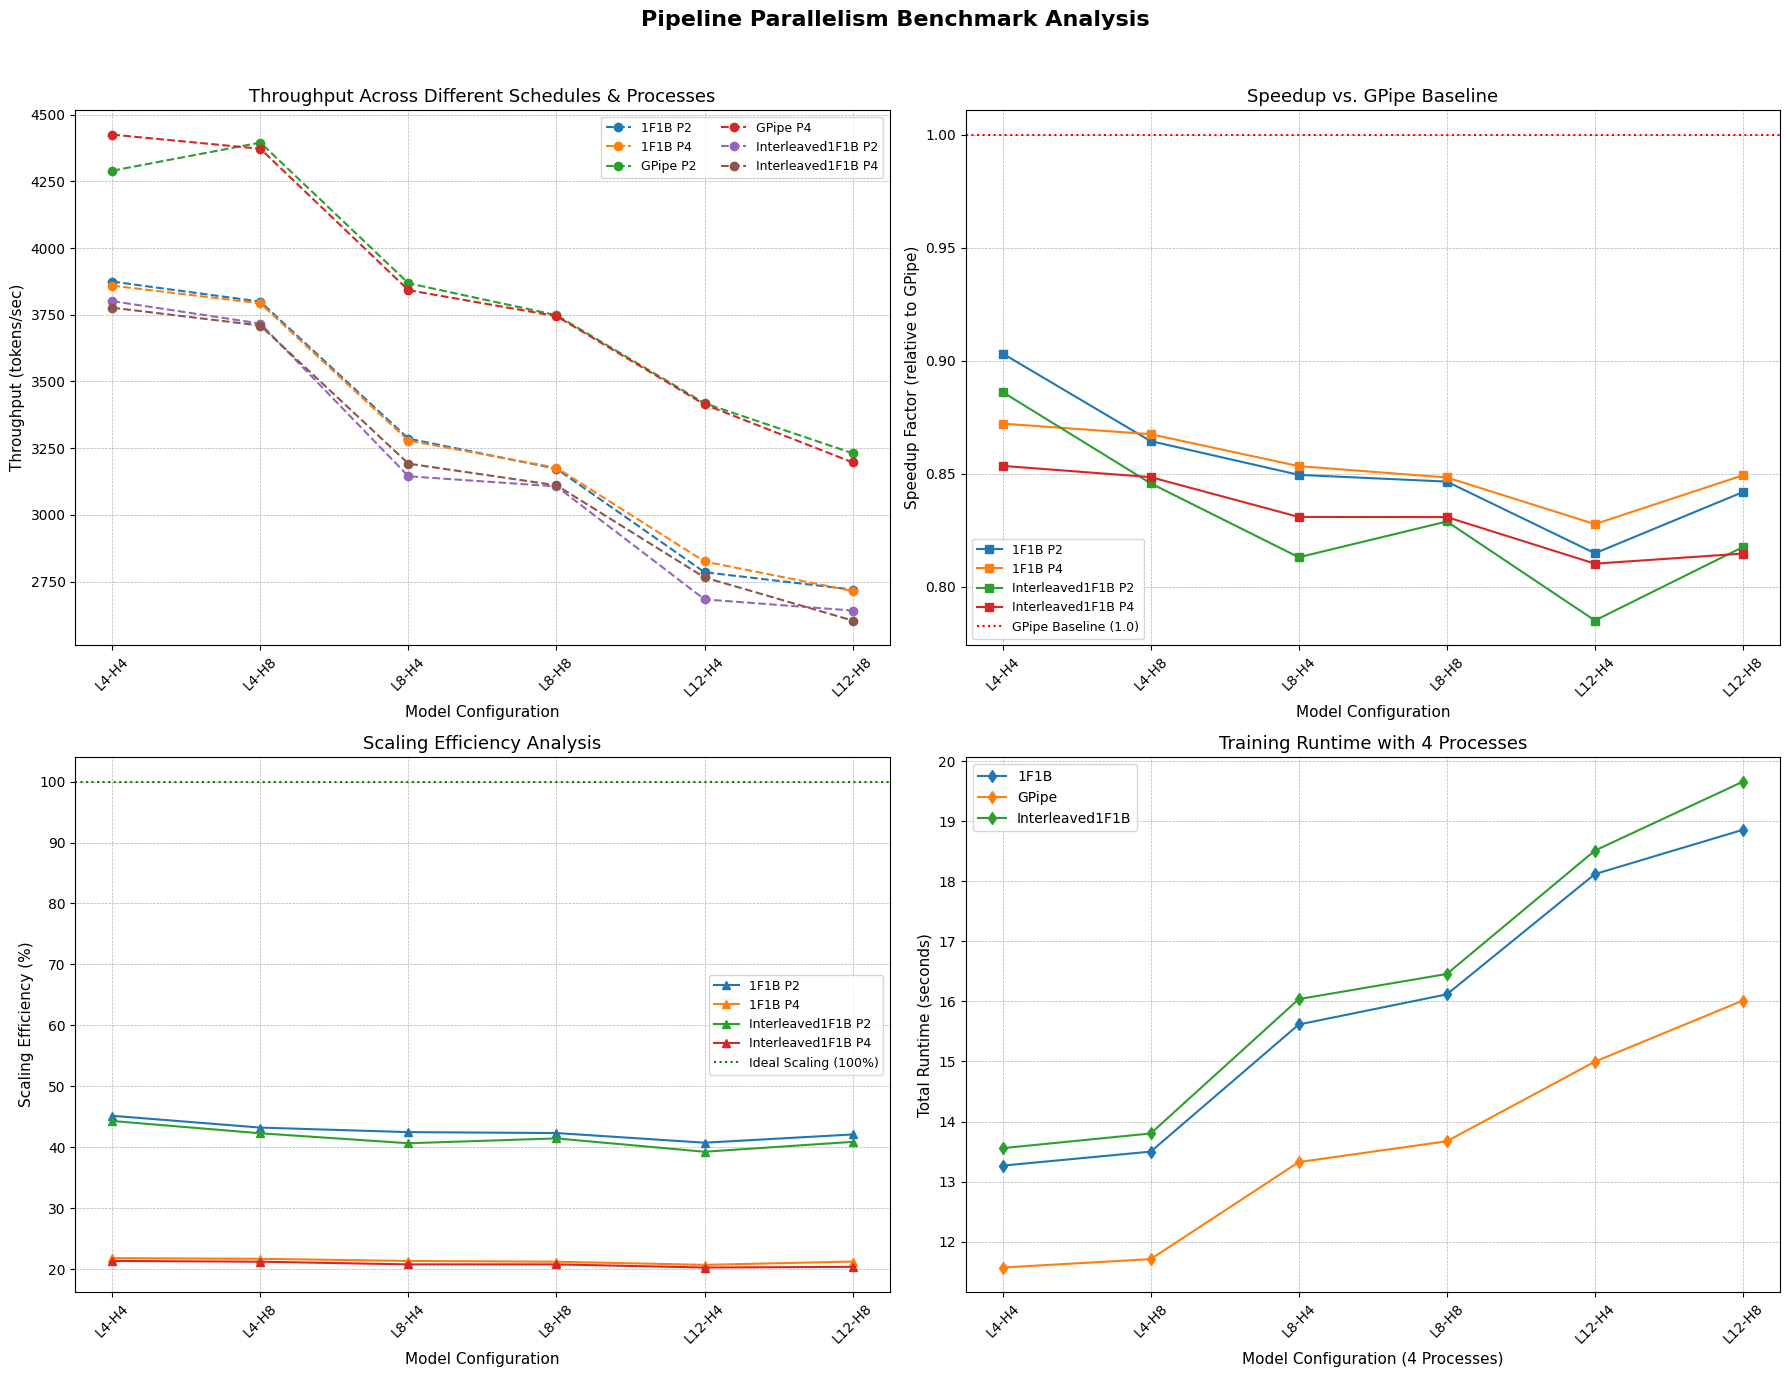

In [8]:
if __name__ == "__main__":
    # Ensure training scripts exist before running
    required_scripts = ['train_gpipe.py', 'train_1f1b.py', 'train_interleaved1f1b.py']
    missing_scripts = [s for s in required_scripts if not os.path.exists(s)]
    if missing_scripts:
        print(f"Error: Missing required training scripts: {', '.join(missing_scripts)}")
        print("Please create these files in the same directory.")
    else:
        main_benchmark()

## Here is the performance_metrics.csv file

```csv
schedule,layers,heads,processes,throughput,speedup_vs_gpipe,scaling_efficiency_pct
1F1B_Schedule,4,4,2,3874.14,0.9031618848685055,45.158094243425275
Interleaved1F1B_Schedule,4,4,2,3801.0,0.8861110657810997,44.305553289054984
1F1B_Schedule,4,4,4,3859.09,0.8721816916178491,21.80454229044623
Interleaved1F1B_Schedule,4,4,4,3776.45,0.8535044659000505,21.337611647501262
1F1B_Schedule,4,8,2,3799.16,0.8644434938519927,43.22217469259964
Interleaved1F1B_Schedule,4,8,2,3717.06,0.8457628352734521,42.288141763672606
1F1B_Schedule,4,8,4,3792.56,0.8675113283635689,21.687783209089222
Interleaved1F1B_Schedule,4,8,4,3709.53,0.8485190209000015,21.212975522500038
1F1B_Schedule,8,4,2,3286.02,0.8495288323573893,42.47644161786946
Interleaved1F1B_Schedule,8,4,2,3145.02,0.8130763563035638,40.653817815178186
1F1B_Schedule,8,4,4,3278.69,0.8533832727310587,21.33458181827647
Interleaved1F1B_Schedule,8,4,4,3192.36,0.8309131465724795,20.772828664311987
1F1B_Schedule,8,8,2,3173.17,0.8465443738361639,42.32721869180819
Interleaved1F1B_Schedule,8,8,2,3107.04,0.8289020857010229,41.445104285051144
1F1B_Schedule,8,8,4,3176.81,0.8483687219763874,21.209218049409685
Interleaved1F1B_Schedule,8,8,4,3111.24,0.8308582202151892,20.77145550537973
1F1B_Schedule,12,4,2,2785.59,0.8148478590275381,40.74239295137691
Interleaved1F1B_Schedule,12,4,2,2683.91,0.7851041672760886,39.25520836380443
1F1B_Schedule,12,4,4,2825.81,0.8277366062274817,20.693415155687042
Interleaved1F1B_Schedule,12,4,4,2766.11,0.8102492750227013,20.256231875567533
1F1B_Schedule,12,8,2,2720.61,0.8419239838832464,42.096199194162324
Interleaved1F1B_Schedule,12,8,2,2642.09,0.8176250688551783,40.88125344275891
1F1B_Schedule,12,8,4,2715.35,0.8493298509563503,21.233246273908758
Interleaved1F1B_Schedule,12,8,4,2604.69,0.8147166919503918,20.367917298759792
```

Based on the CSV performance results, the **GPipe schedule is the most effective** for all model configurations in this CPU-based test.

***

### Best Performing Schedule

* **Answer: GPipe**
    GPipe consistently provides the **highest throughput** and **lowest runtime**. Its simple execution model minimizes the frequency of communication between processes, which is more efficient in a CPU environment where communication overhead is high.

* **Underperformers: 1F1B and Interleaved 1F1B**
    Both 1F1B schedules are slower than GPipe, with speedup factors always below 1.0. They are designed to reduce idle time ("bubbles") by overlapping forward and backward passes, but this requires frequent synchronization that creates a bottleneck on CPUs. Between the two, **1F1B is slightly better than Interleaved 1F1B**, as the latter introduces even more communication overhead.

***

### Performance Scaling

* **Scaling with Model Size**
    As expected, performance **degrades as the model size increases** (more layers and heads) for all schedules. This is due to the higher computational and communication load required for larger models, leading to lower throughput and longer runtimes.

* **Scaling with Processes**
    Adding more processes shows **poor scaling efficiency**. The efficiency drops from an average of **~42%** with 2 processes to **~21%** with 4 processes. This significant drop indicates that the cost of communication and synchronization across multiple CPU cores outweighs the benefits of added parallel computation, creating a major performance bottleneck.